In [1]:
import os
import argparse
import glob

import librosa
import scipy
import numpy as np
from scipy.signal import lfilter
import soundfile as sf
from noisereduce import reduce_noise
import matplotlib.pyplot as plt


import phast
import bruce

from notebooks import utils, plotting
from run_reconstruction import *



In [86]:
bruce.set_seed(31)
path = "data/din/198.wav"

maxes = []

for db in range(10, 300, 10):
    print(db)
    stim = bruce.stimulus.from_file(path, False)
    stim = bruce.stimulus.normalize_db(stim, db)

    n_trials = 20
    n_fibers = 10

    n_low_med = int(np.floor(n_fibers / 5))
    n_high = n_fibers - (2 * n_low_med)

    min_freq = 150
    max_freq = 10_500
    n_bins = 1
    n_mels = 64 

    mel_scale = librosa.filters.mel_frequencies(n_mels, fmin=min_freq, fmax=max_freq)

    ng = bruce.Neurogram(
        mel_scale,
        n_low=n_low_med,
        n_med=n_low_med,
        n_high=n_high,
    )
    # Takes more time
    ng.bin_width = 1 / (max_freq * 2 * n_bins)
    from time import perf_counter

    time = perf_counter()
    ng.create(stim, n_rep=1, n_trials=n_trials)
    echo(perf_counter() - time)

    data = ng.get_output()
    echo("n spikes", data.sum())
    echo(data.min(), data.max())
    
    maxes.append(data.max(axis=1))

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290


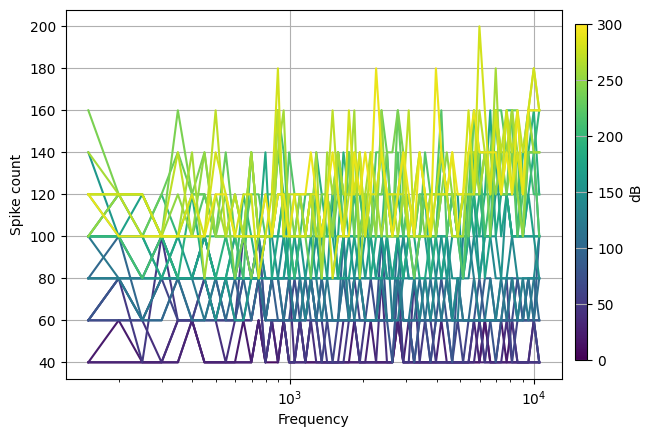

In [89]:
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
norm = mcolors.Normalize(vmin=0, vmax=300)
cmap = plt.cm.viridis

fig, ax = plt.subplots()
for i, db in enumerate(range(10, 300, 10)):
    ax.plot(mel_scale, maxes[i], color=cmap(norm(db)))
    
plt.xscale('log')
plt.xlabel("Frequency")
plt.ylabel("Spike count")
plt.grid()
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
cb = mcolorbar.ColorbarBase(ax=cbar_ax, cmap=cmap, norm=norm, label='dB')

plt.grid()

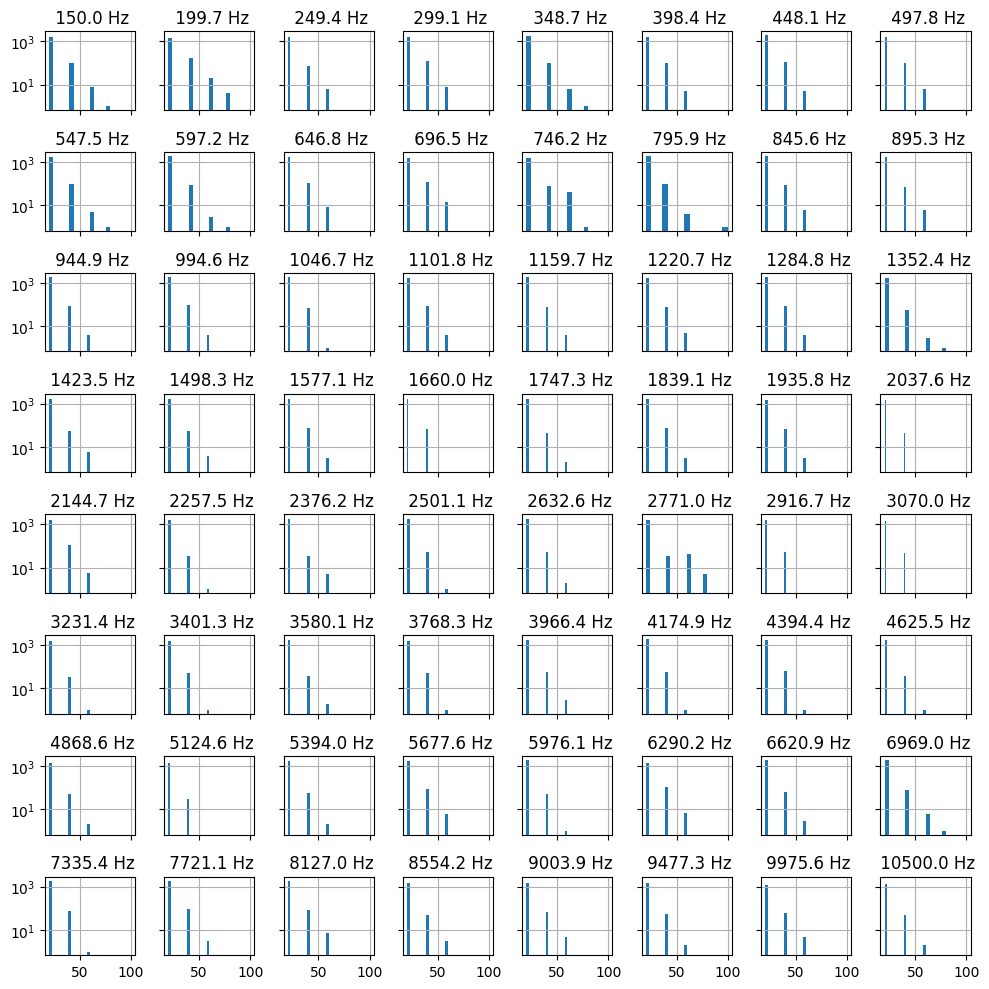

In [27]:
f, axes = plt.subplots(8, 8, figsize=(10, 10), sharex=True, sharey=True)
t = np.arange(data.shape[1]) * ng.bin_width
for i, ax in enumerate(axes.ravel()):
    dt = data[i]
    ax.hist(dt[np.nonzero(dt)], bins=15)
    ax.set_title(f"{mel_scale[i]: .1f} Hz")
    ax.grid()
    ax.set_yscale("log")
plt.tight_layout()